Using device: cuda
Generated 4615 trade events with strong, distinct patterns.
Created a full dataset with 4605 sequences.
Data split into 3684 training samples and 921 testing samples.

--- Starting Training on Corrected Architecture ---
Epoch 00, Training Loss: 1.0596
Epoch 01, Training Loss: 0.9177
Epoch 02, Training Loss: 0.9082
Epoch 03, Training Loss: 0.8820
Epoch 04, Training Loss: 0.8832
--- Training Finished ---

--- Starting Backtest on Unseen Data ---

--- Backtest Results ---
Total test samples: 921
Correct predictions: 707
Accuracy on Test Set: 76.76%
------------------------

--- Generating Confusion Matrix ---


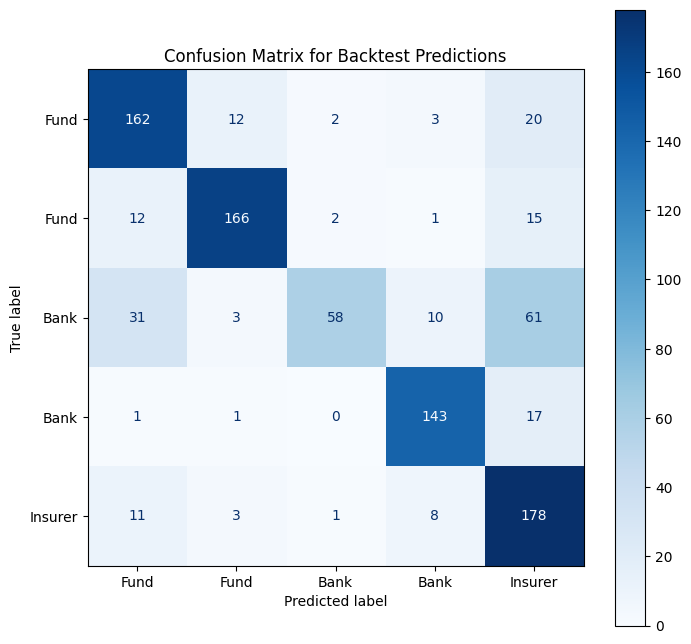

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv, Linear
import numpy as np
import random
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import copy
from collections import Counter


# --- 0. Set cuda / mps torch device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 1. Final, Pattern-Driven Data Generator ---

CLIENTS = ['C1_Fund', 'C2_Fund', 'C3_Bank', 'C4_Bank', 'C5_Insurer']
CLIENT_TYPES = ['Fund', 'Bank', 'Insurer']
client_to_type_map = {'C1_Fund':'Fund', 'C2_Fund':'Fund', 'C3_Bank':'Bank', 'C4_Bank':'Bank', 'C5_Insurer':'Insurer'}
FX_PAIRS = ['EURUSD', 'USDJPY', 'GBPUSD']
client_to_pairs_map = {
    'C1_Fund': ['EURUSD', 'USDJPY'], 'C2_Fund': ['EURUSD', 'GBPUSD'],
    'C3_Bank': ['GBPUSD', 'USDJPY'], 'C4_Bank': ['USDJPY'], 'C5_Insurer': ['EURUSD']
}

def generate_trade_events_final(num_days=10000): # More data
    trade_events = []
    start_date = datetime(2023, 1, 1)
    base_probs = {'Fund': 0.01, 'Bank': 0.01, 'Insurer': 0.02}

    for day_offset in range(num_days):
        current_date = start_date + timedelta(days=day_offset)
        is_month_start = current_date.day <= 3
        is_month_end = (pd.to_datetime(current_date) + pd.tseries.offsets.BMonthEnd(0)).day - current_date.day < 2
        is_mid_month = 14 <= current_date.day <= 16

        for client in CLIENTS:
            client_type = client_to_type_map[client]
            trade_prob = base_probs[client_type]
            if client_type == 'Fund' and is_month_start: trade_prob = 0.9
            if client_type == 'Bank' and is_month_end: trade_prob = 0.95
            if client_type == 'Insurer' and is_mid_month: trade_prob = 0.8
            if random.random() < trade_prob:
                trade_events.append({'time': current_date, 'client': client})

    trade_events.sort(key=lambda x: x['time'])
    return trade_events

trade_events = generate_trade_events_final()
print(f"Generated {len(trade_events)} trade events with strong, distinct patterns.")

# --- 2. Data Preparation (No Changes) ---
data_template = HeteroData()
client_map = {name: i for i, name in enumerate(CLIENTS)}
type_map = {name: i for i, name in enumerate(CLIENT_TYPES)}
pair_map = {name: i for i, name in enumerate(FX_PAIRS)}

data_template['client'].x = torch.zeros(len(CLIENTS), 1)
data_template['client_type'].x = torch.eye(len(CLIENT_TYPES))
data_template['fx_pair'].x = torch.eye(len(FX_PAIRS))

client_type_edges = [(client_map[c], type_map[t]) for c, t in client_to_type_map.items()]
client_pair_edges = [(client_map[c], pair_map[p]) for c, ps in client_to_pairs_map.items() for p in ps]

data_template['client', 'is_type', 'client_type'].edge_index = torch.tensor(client_type_edges, dtype=torch.long).t().contiguous()
data_template['client', 'trades', 'fx_pair'].edge_index = torch.tensor(client_pair_edges, dtype=torch.long).t().contiguous()
data_template['client_type', 'rev_is_type', 'client'].edge_index = data_template['client', 'is_type', 'client_type'].edge_index.flip([0])
data_template['fx_pair', 'rev_trades', 'client'].edge_index = data_template['client', 'trades', 'fx_pair'].edge_index.flip([0])

def create_dataset_final(events, seq_len=10):
    dataset = []
    for i in range(len(events) - seq_len):
        sequence_events = events[i : i + seq_len]
        label_event = events[i + seq_len]
        snapshot_sequence = []
        for j in range(seq_len):
            snapshot_event = sequence_events[j]
            snapshot_time = snapshot_event['time']
            last_trade_times = {c: snapshot_time - timedelta(days=365) for c in CLIENTS}
            for event in events[:i+j+1]:
                 last_trade_times[event['client']] = event['time']
            client_features = [[(snapshot_time - last_trade_times[c]).days] for c in CLIENTS]

            x_dict = {
                'client': torch.tensor(client_features, dtype=torch.float),
                'client_type': data_template['client_type'].x,
                'fx_pair': data_template['fx_pair'].x,
            }
            snapshot_sequence.append(x_dict)
        label = client_map[label_event['client']]
        dataset.append((snapshot_sequence, torch.tensor(label, dtype=torch.long)))
    return dataset

full_dataset = create_dataset_final(trade_events)
split_ratio = 0.8
split_index = int(len(full_dataset) * split_ratio)
train_dataset = full_dataset[:split_index]
test_dataset = full_dataset[split_index:]
print(f"Created a full dataset with {len(full_dataset)} sequences.")
print(f"Data split into {len(train_dataset)} training samples and {len(test_dataset)} testing samples.")

# --- 3. The Final, Corrected GNN Model Architecture ---
class TemporalHGNN_Final(nn.Module):
    def __init__(self, hidden_channels, num_clients):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.num_clients = num_clients

        self.conv1 = HeteroConv({
            meta: SAGEConv(-1, hidden_channels) for meta in data_template.metadata()[1]
        }, aggr='sum')

        self.gru = nn.GRU(hidden_channels, hidden_channels, batch_first=True)

        self.classifier = nn.Sequential(
            Linear(hidden_channels * num_clients, hidden_channels),
            nn.ReLU(),
            Linear(hidden_channels, num_clients)
        )

    def forward(self, snapshot_sequence, edge_index_dict):
        client_embeds_over_time = []
        for x_dict in snapshot_sequence:
            x_dict_out = self.conv1(x_dict, edge_index_dict)
            client_embeds_over_time.append(x_dict_out['client'])

        client_sequences_tensor = torch.stack(client_embeds_over_time, dim=0).permute(1, 0, 2)
        gru_out, _ = self.gru(client_sequences_tensor)
        final_client_reps = gru_out[:, -1, :]
        final_vector = final_client_reps.reshape(1, -1)
        out = self.classifier(final_vector)
        return F.log_softmax(out, dim=-1)

# --- 4. Training Loop (Longer) ---
hidden_dim = 64
model = TemporalHGNN_Final(hidden_channels=hidden_dim, num_clients=len(CLIENTS))
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
print(f"\n--- Starting Training on Corrected Architecture ---")
model.train()
for epoch in range(5): # Abridged training for demonstration
    random.shuffle(train_dataset)
    total_loss = 0
    for sequence, label in train_dataset:
        optimizer.zero_grad()
        out = model(sequence, data_template.edge_index_dict)
        loss = F.nll_loss(out, label.unsqueeze(0))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 1 == 0:
        print(f"Epoch {epoch:02d}, Training Loss: {total_loss/len(train_dataset):.4f}")
print("--- Training Finished ---\n")

# --- 5. Backtesting Loop ---
print("--- Starting Backtest on Unseen Data ---")
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for i, (sequence, label_tensor) in enumerate(test_dataset):
        out = model(sequence, data_template.edge_index_dict)
        pred_idx = out.argmax(dim=-1).item()
        actual_idx = label_tensor.item()
        all_preds.append(pred_idx)
        all_labels.append(actual_idx)

# --- 6. Report Metrics ---
accuracy = (np.sum(np.array(all_preds) == np.array(all_labels)) / len(test_dataset)) * 100
print("\n--- Backtest Results ---")
print(f"Total test samples: {len(test_dataset)}")
print(f"Correct predictions: {int(accuracy/100 * len(test_dataset))}")
print(f"Accuracy on Test Set: {accuracy:.2f}%")
print("------------------------\n")

# --- 7. VISUALIZATIONS ---
print("--- Generating Confusion Matrix ---")
short_client_names = [name.split('_')[1] for name in CLIENTS]
cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(CLIENTS))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_client_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Backtest Predictions")
plt.show()



Found a correct prediction for C1_Fund to explain at test set index 1.

--- Explanation for Prediction ---
Input Sequence Length: 5 time steps.
Model Predicted: C1_Fund (Correct: True)
Actual Next Trader: C1_Fund
--------------------------------

The heatmap below shows feature importance (saliency).
Brighter cells indicate that the 'days since last trade' for that client at that time step was highly influential for the final decision.



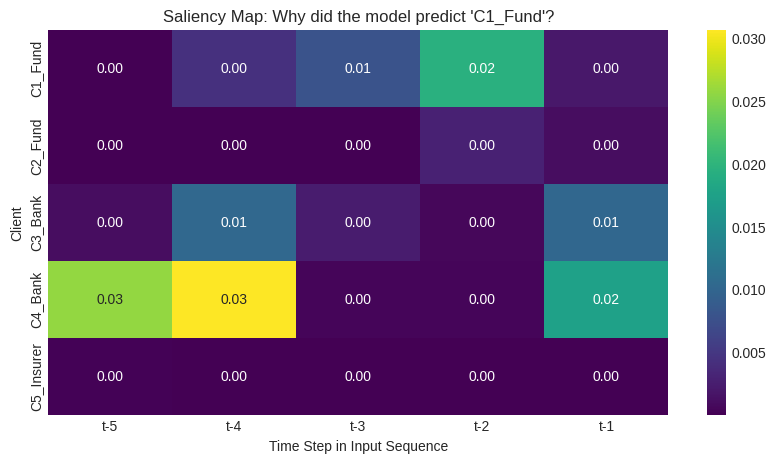

In [ ]:
# --- 8. Model Explainability using Gradient Saliency ---
import seaborn as sns
import copy

def explain_prediction(model, sequence, label_idx, pred_idx, client_map):
    """
    Generates an explanation for a single prediction using gradient saliency.
    """
    # Reverse map for easy lookup
    idx_to_client = {i: name for name, i in client_map.items()}

    # --- Step 1: Prepare the model and input for gradient calculation ---
    model.eval()
    model.zero_grad()

    # We need to deepcopy the sequence and enable gradient tracking on the features
    # we want to inspect. In this case, it's the 'client' features.
    sequence_copy = copy.deepcopy(sequence)
    for snapshot in sequence_copy:
        snapshot['client'].requires_grad = True

    # --- Step 2: Run the forward pass and backpropagate from the winning score ---
    # Get the model's raw output scores (logits before softmax)
    out_logits = model(sequence_copy, data_template.edge_index_dict)

    # Isolate the score for the specific class that was predicted
    score_for_pred_class = out_logits[0, pred_idx]

    # Backpropagate from this single score to calculate gradients
    score_for_pred_class.backward()

    # --- Step 3: Extract and visualize the gradients ---
    saliency_data = []
    for snapshot in sequence_copy:
        # .grad contains the gradients we need. We take the absolute value.
        saliency_data.append(snapshot['client'].grad.abs().squeeze(dim=-1).numpy())

    # Create a heatmap of the saliency scores
    saliency_matrix = np.array(saliency_data).T # Transpose to get [clients, timesteps]

    actual_client = idx_to_client[label_idx]
    predicted_client = idx_to_client[pred_idx]

    print(f"\n--- Explanation for Prediction ---")
    print(f"Input Sequence Length: {len(sequence)} time steps.")
    print(f"Model Predicted: {predicted_client} (Correct: {predicted_client == actual_client})")
    print(f"Actual Next Trader: {actual_client}")
    print("--------------------------------\n")
    print("The heatmap below shows feature importance (saliency).")
    print("Brighter cells indicate that the 'days since last trade' for that client at that time step was highly influential for the final decision.\n")

    plt.figure(figsize=(10, 5))
    sns.heatmap(
        saliency_matrix,
        xticklabels=[f"t-{len(sequence)-i}" for i in range(len(sequence))],
        yticklabels=[name for name in CLIENTS],
        cmap="viridis",
        annot=True,
        fmt=".2f"
    )
    plt.xlabel("Time Step in Input Sequence")
    plt.ylabel("Client")
    plt.title(f"Saliency Map: Why did the model predict '{predicted_client}'?")
    plt.show()


# --- Find an interesting prediction to explain ---
# Let's find a correct prediction for a 'Fund' client, as they have strong patterns.
sample_to_explain_idx = -1
for i, (label_idx, pred_idx) in enumerate(zip(all_labels, all_preds)):
    # Find a correct prediction for 'C1_Fund'
    if label_idx == pred_idx and client_map['C1_Fund'] == label_idx:
        sample_to_explain_idx = i
        break

if sample_to_explain_idx != -1:
    print(f"Found a correct prediction for C1_Fund to explain at test set index {sample_to_explain_idx}.")
    sequence_to_explain, label_to_explain = test_dataset[sample_to_explain_idx]
    pred_to_explain = all_preds[sample_to_explain_idx]
    explain_prediction(model, sequence_to_explain, label_to_explain.item(), pred_to_explain, client_map)
else:
    print("Could not find a specific correct prediction for 'C1_Fund' in the test set to explain.")

In [2]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.8 MB/s eta 0:00:00
